In [1]:
from sf_workingdir_lilly.dmlab.custom_esn_analysis import get_hidden_states_iso_feat
import torch
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# define parameters
time_steps = 70
#[0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.92, 0.95, 0.97, 0.99]
spectral_radius = [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0] #[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 2, 3, 4, 5, 6, 7, 8]
Hippo_n_feature = 16
Hippo_R = 8
Hippo_L = 64
trial=6
fixed_whh=True
fixed_wih=False

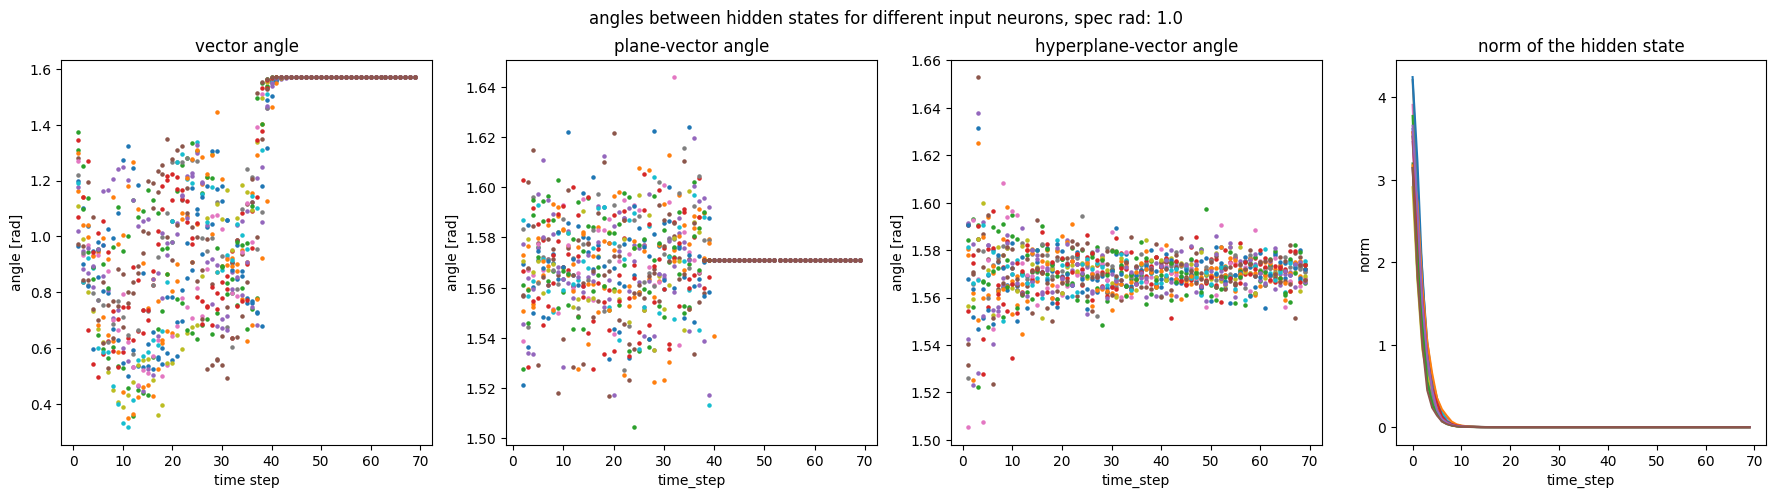

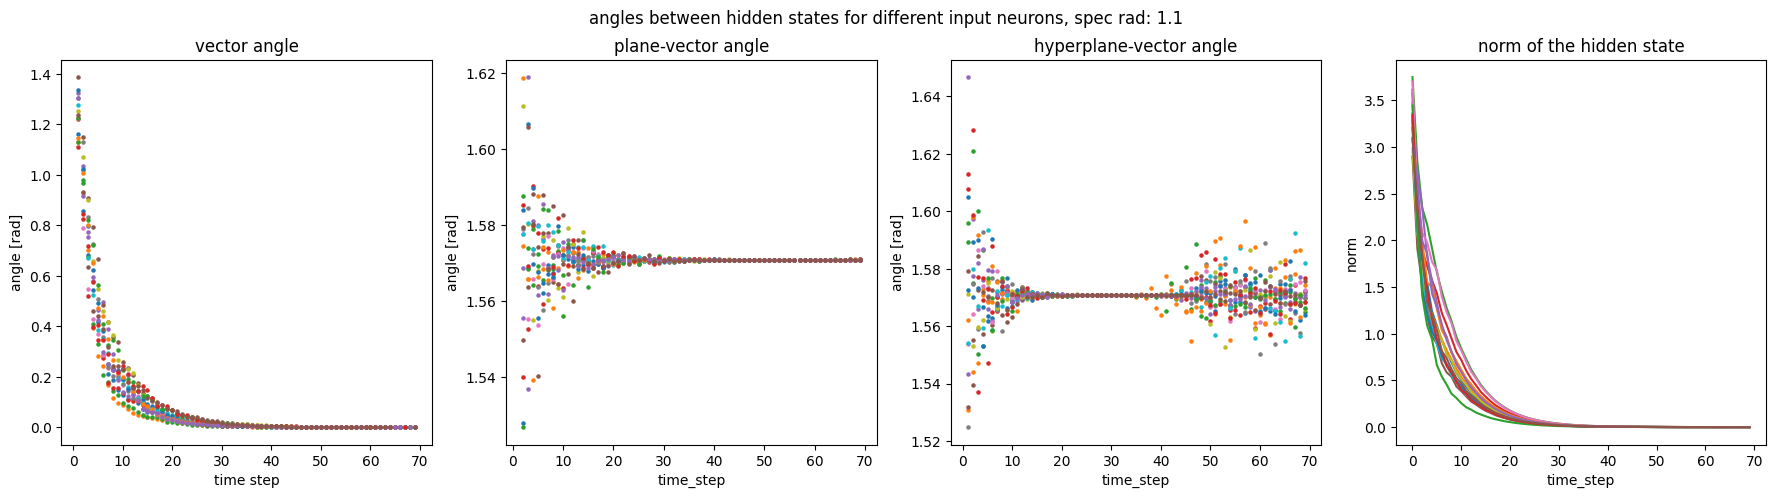

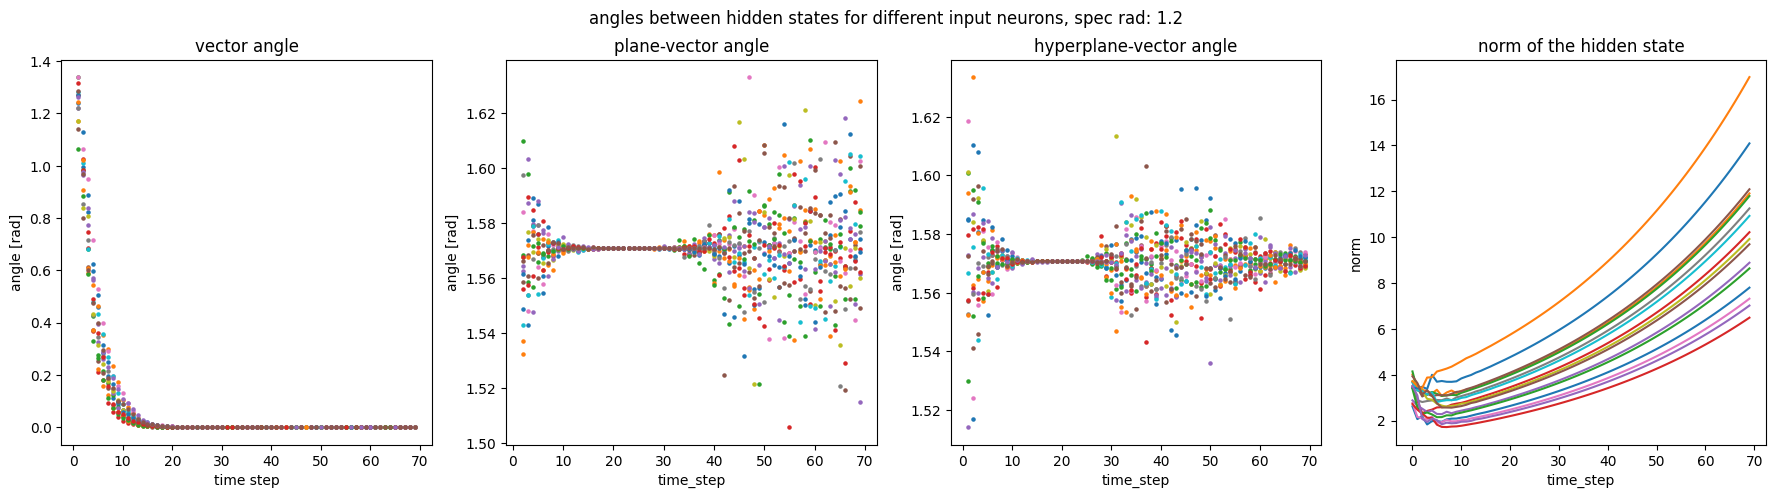

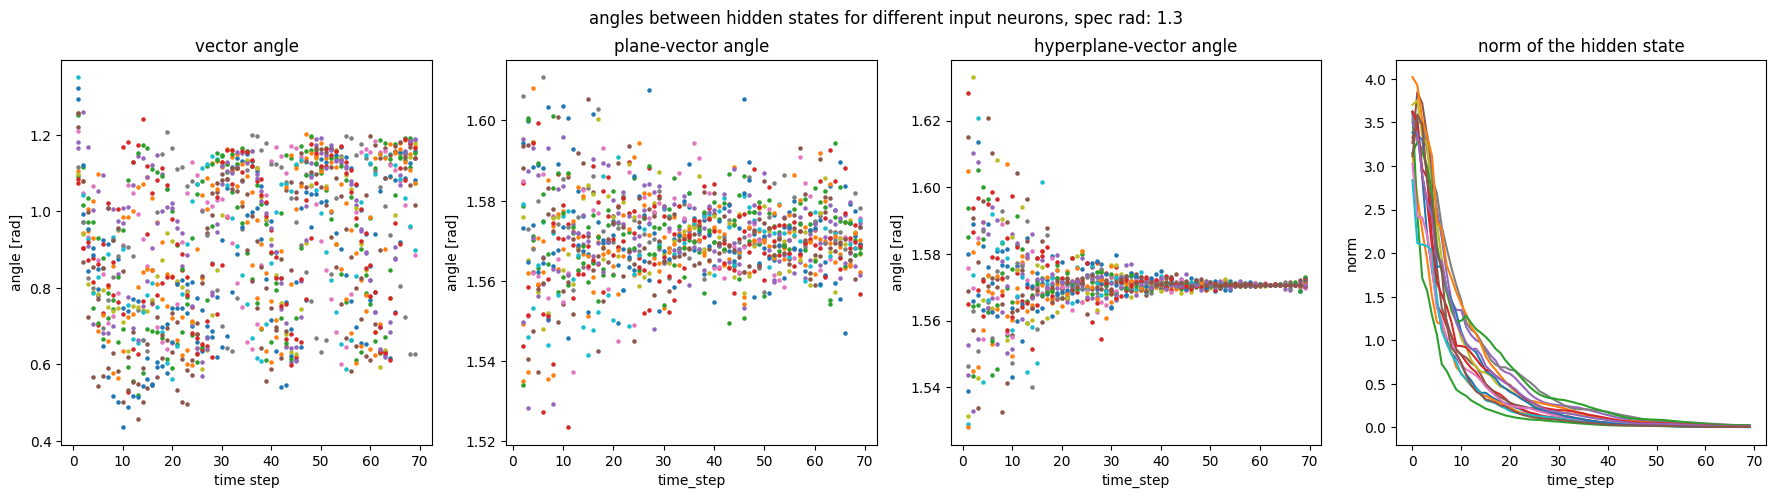

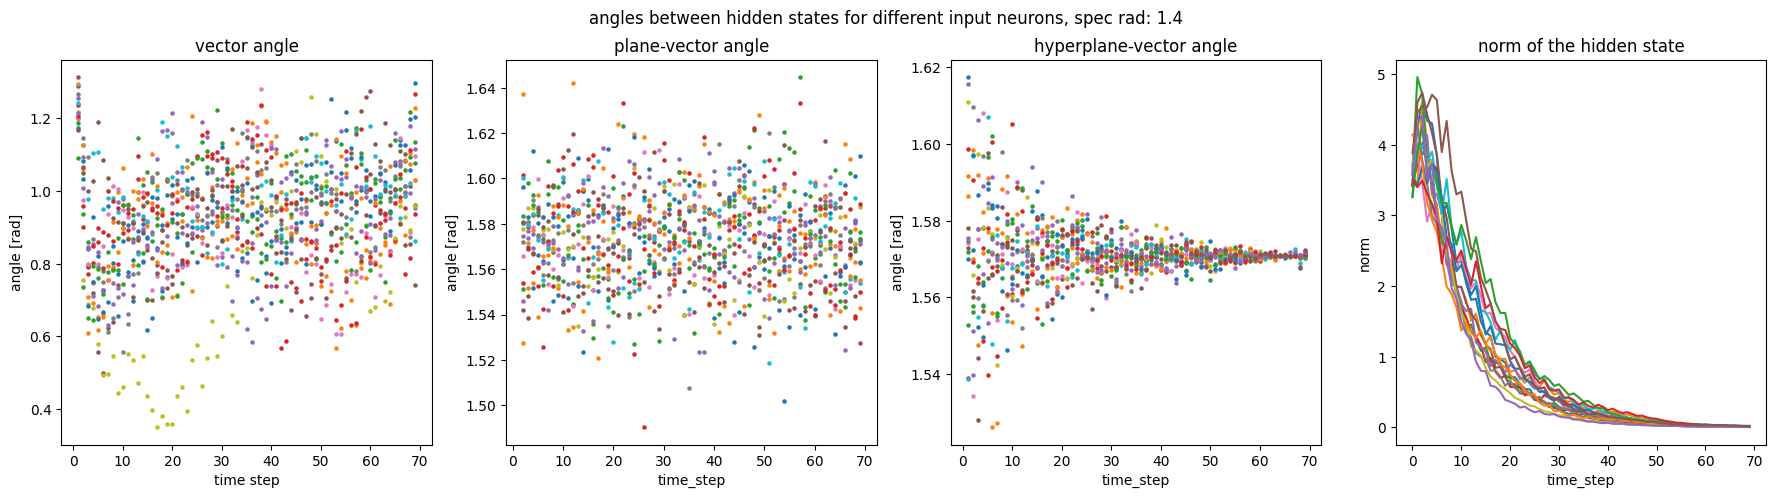

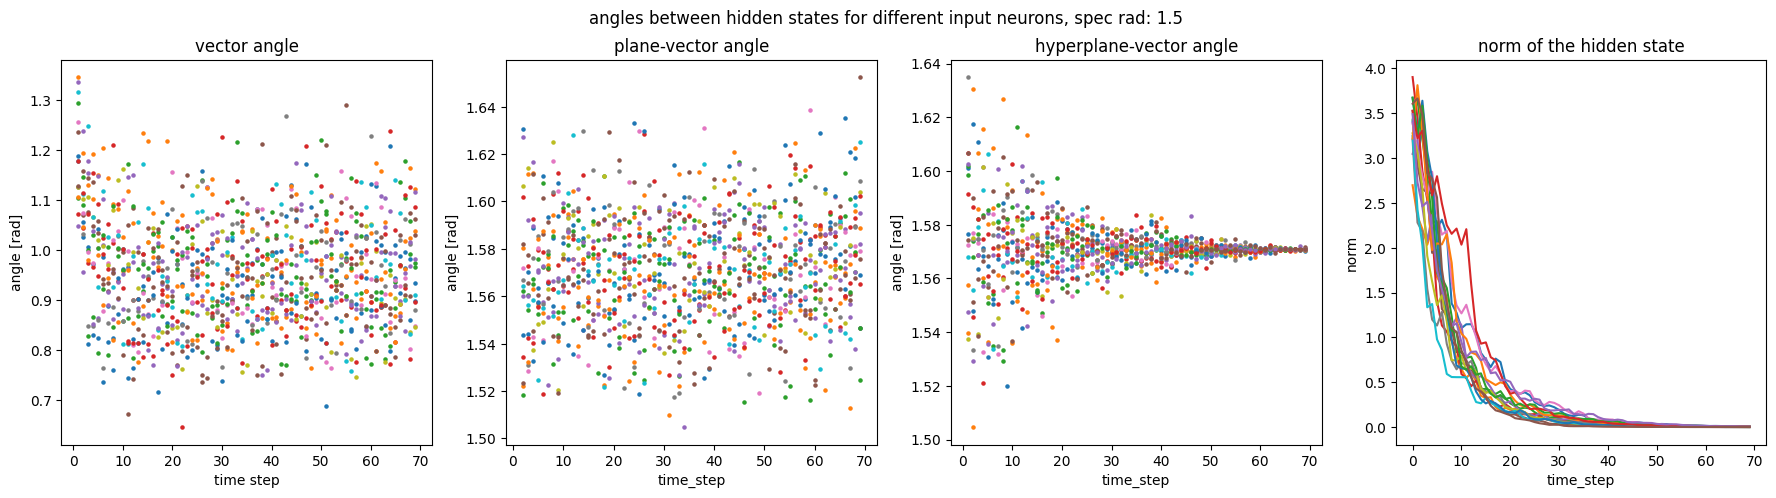

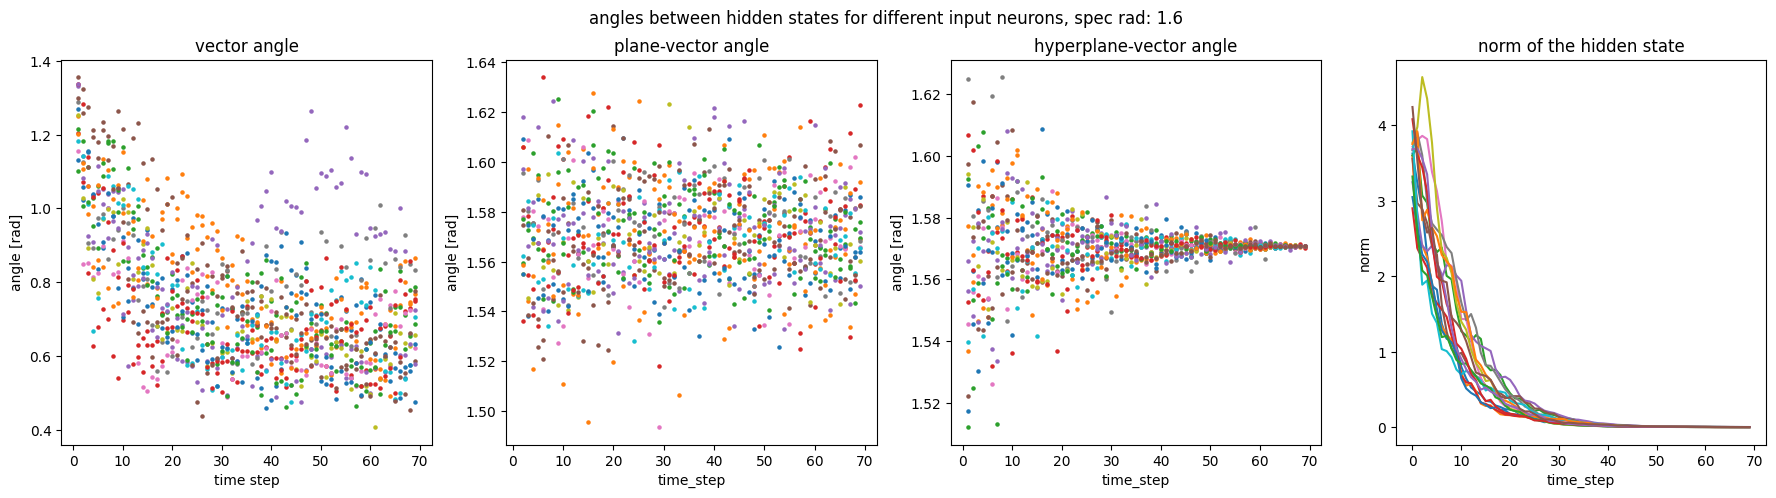

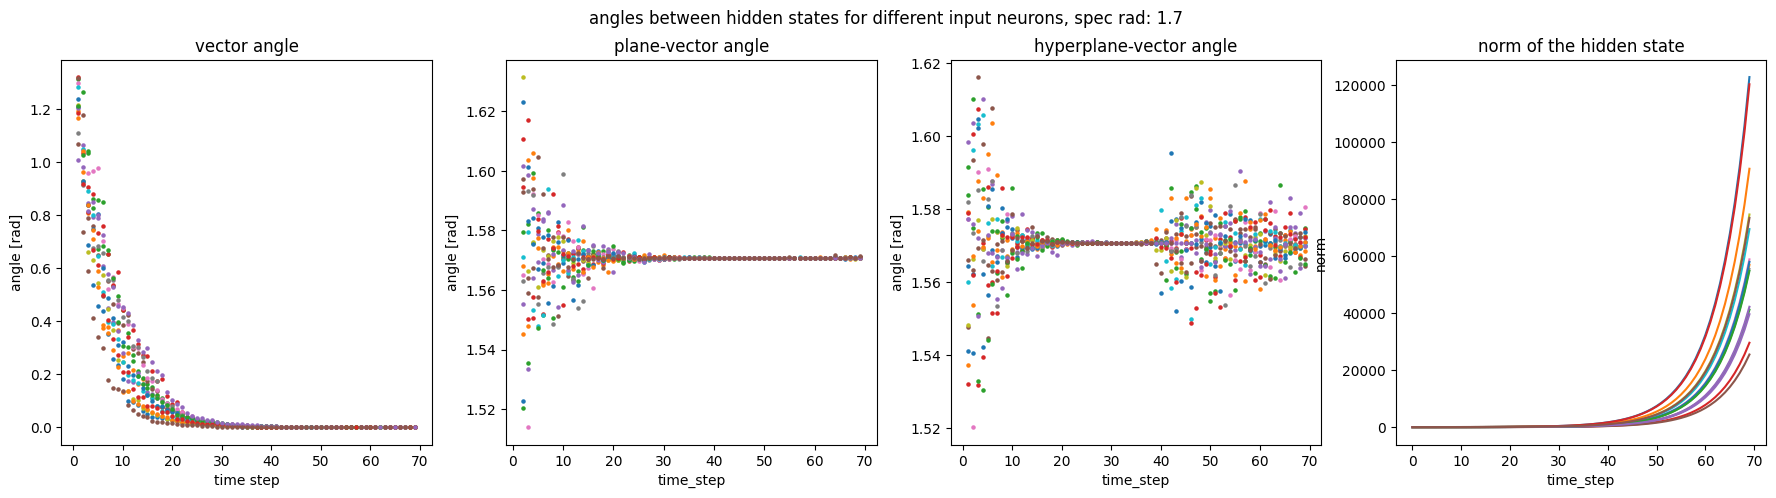

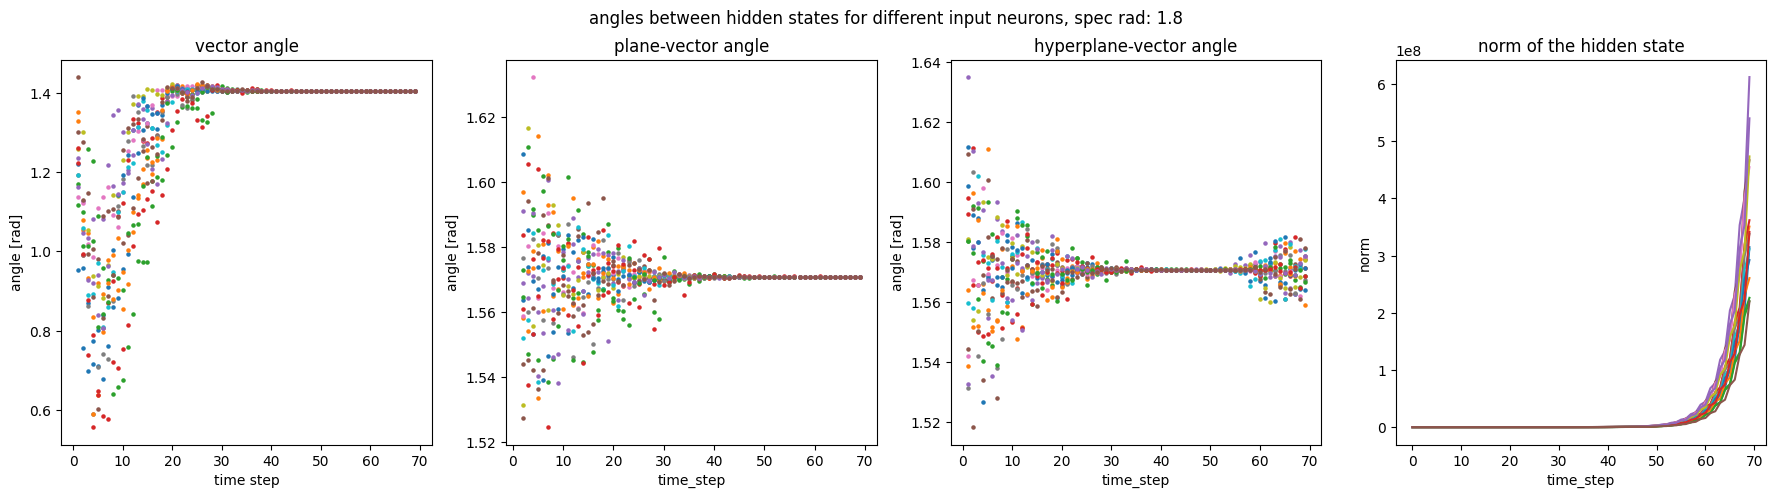

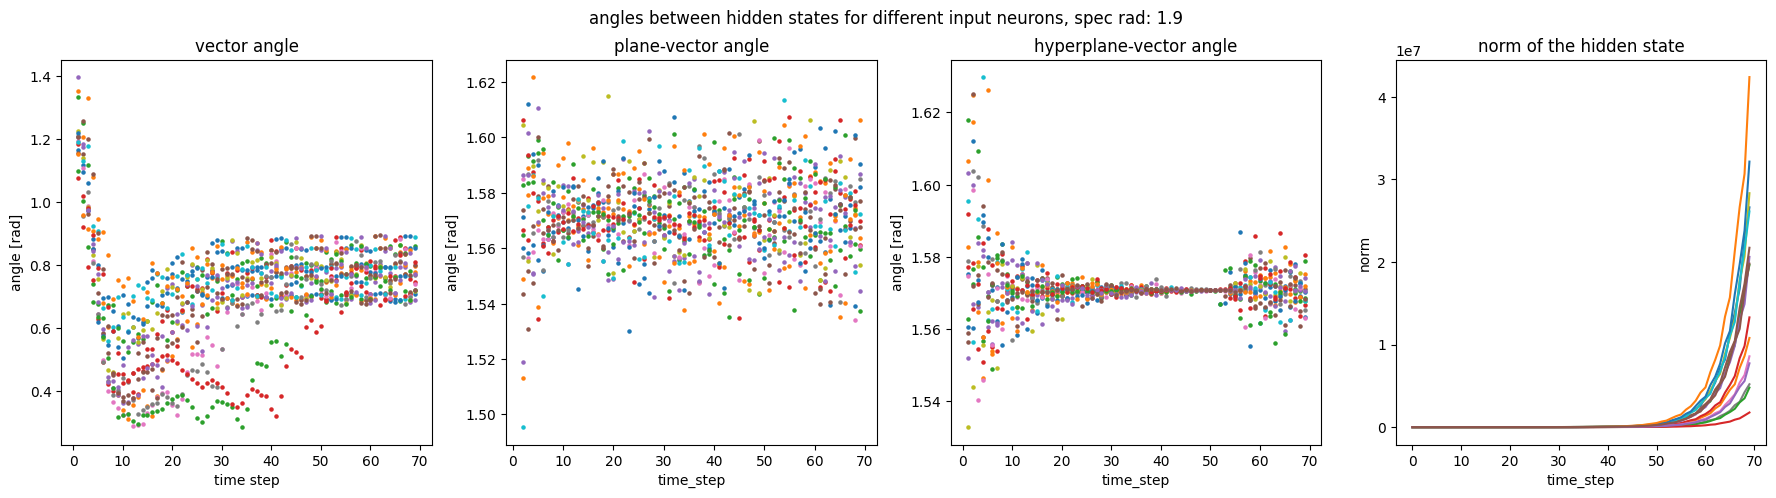

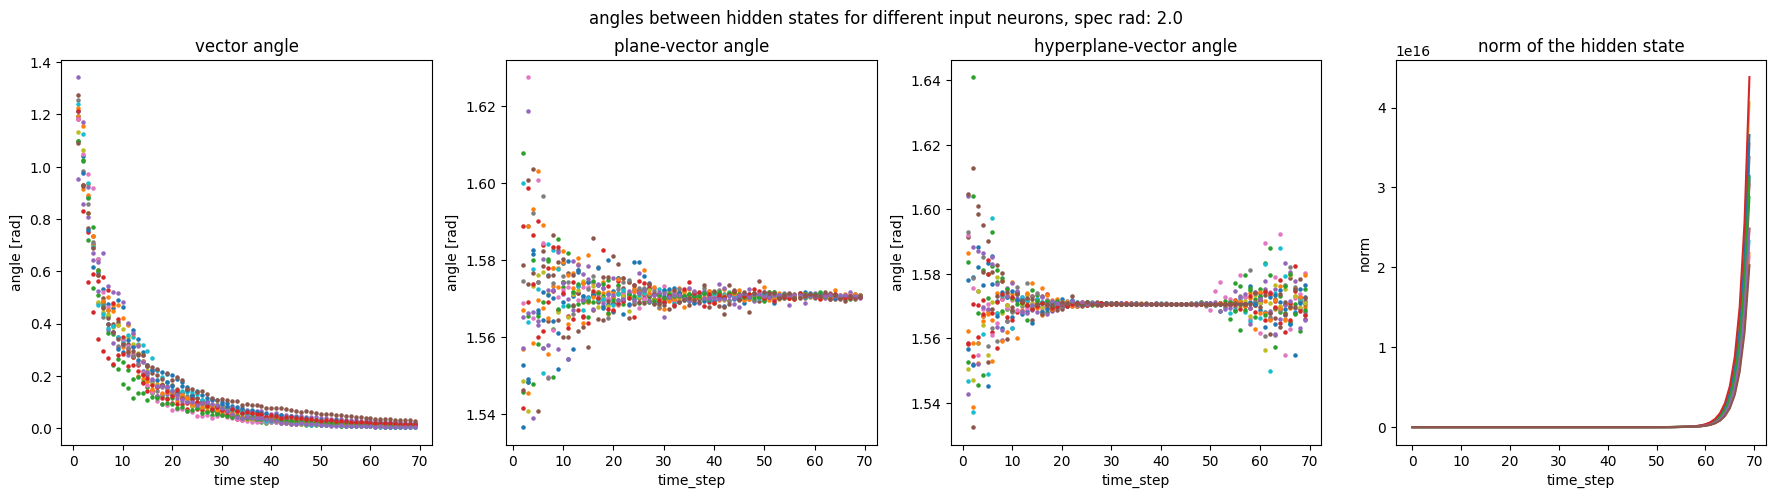

In [3]:
from sf_workingdir_lilly.dmlab.custom_esn_analysis import compute_angle_between_hidden_states, compute_angle_hypperplane_hidden_state, compute_angle_plane_hidden_state


#neuron_norms_for_srs = np.zeros((len(spectral_radius), Hippo_n_feature,time_steps))
x_vals = np.arange(1,70)
x_vals_plane = np.arange(2,70)

for sr_i, sr in enumerate(spectral_radius):
    # create a (input_index, time_steps) matrix for each spectral radius - values in the matrix are the norms at this input index at that tiem - and create a plot where the norms are plotted against the time
    #neuron_norms = np.zeros((Hippo_n_feature,time_steps))
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1,4, figsize=(22,5))
    for i in range(Hippo_n_feature):
        hs = get_hidden_states_iso_feat(time_steps, sr, Hippo_n_feature, Hippo_R, Hippo_L, trial, fixed_whh, fixed_wih, input_idx=i)  # size: (time_steps, hidden_size)
        angles = compute_angle_between_hidden_states(hs, time_steps)
        angles_plane = compute_angle_plane_hidden_state(hs, time_steps)
        angles_hyperplane = compute_angle_hypperplane_hidden_state(hs, time_steps)

        norms = hs.norm(dim=1)
        
        #neuron_norms[i,:] = norms
        #neuron_norms_for_srs[sr_i,i,:] = norms
        
        ax1.scatter(x_vals, angles, label=f'{i}', s=5)
        ax2.scatter(x_vals_plane, angles_plane, label=f'{i}', s=5)
        ax3.scatter(x_vals, angles_hyperplane, label=f'{i}', s=5)
        ax4.plot(norms, label=f'{i}')
    
        fig.suptitle(f'angles between hidden states for different input neurons, spec rad: {sr}')
        ax1.set_title('vector angle')
        ax2.set_title('plane-vector angle')
        ax3.set_title('hyperplane-vector angle')
        ax4.set_title('norm of the hidden state')

        ax1.set_xlabel('time step')
        ax2.set_xlabel('time_step')
        ax3.set_xlabel('time_step')
        ax4.set_xlabel('time_step')

        ax1.set_ylabel('angle [rad]')
        ax2.set_ylabel('angle [rad]')
        ax3.set_ylabel('angle [rad]')
        ax4.set_ylabel('norm')